In [1]:
import numpy as np
import torch

import os
from tqdm import tqdm
import sys
sys.path.append("..")
from sklearn.decomposition import PCA
from CricaVPR.dataloaders.train.GSVCitiesDataset import GSVCitiesDataset
from datasets_ws import BaseDataset,TripletsDataset
import torchvision.transforms as T
from torch.utils.data.dataset import Subset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib as mpl
from util import boq_output_only_model
from tqdm import tqdm

np.random.seed(0)

In [2]:
os.environ["CUDA_VISIBLE_DEVICES"]=str(6)

In [3]:
train_data='gsv'
method='crica'
dataset='nordland'
lr=1e-7
num="17" 
patience=None
saved_path_log= f"../logs/{train_data}_{method}/logfile{train_data}_{method}_finetuned_on_{dataset}_{lr}_{num}.pth"
saved_path_model= f"../logs/best_model_{train_data}_{method}/{train_data}_{method}_finetuned_on_{dataset}_{lr}_{num}.pth"
# saved_path= "logs/gsv_crica/logfilegsv_crica_finetuned_on_nordland.pth1e-05"
logfile=torch.load(saved_path_log)
args=logfile['args']
original_model=True

In [4]:
method="boq"

if method=="boq":
    image_size=[322,322]
    descriptors_dimension = 12288

        
    model = torch.hub.load("amaralibey/bag-of-queries", "get_trained_boq", backbone_name="dinov2", output_dim=12288)
    
    model=boq_output_only_model(model)
#     for param in model.backbone.named_parameters():
#         if param[1].requires_grad:
#             param[1].requires_grad=False

    
elif method == "crica":
    image_size=[224,224]
    descriptors_dimension = 10752
    model=torch.hub.load("Lu-Feng/CricaVPR", "trained_model")
    args.features_dim=descriptors_dimension
elif method == "salad":
    image_size=[322,322]
    descriptors_dimension=8448
    features_dim=descriptors_dimension
    model = torch.hub.load("serizba/salad", "dinov2_salad")
    
    
if not original_model:
    state_dict=torch.load(saved_path_model)["model_state_dict"]
    model.load_state_dict()
model.cuda()
model.eval()

Using cache found in /home/osverburg/.cache/torch/hub/amaralibey_bag-of-queries_main
Using cache found in /home/osverburg/.cache/torch/hub/facebookresearch_dinov2_main
/home/osverburg/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/osverburg/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/osverburg/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [5]:
wanted_datasets=["amstertime","nordland","eynsham","sped"]
# wanted_datasets=["amstertime"]
# wanted_dataset2="amstertime"

In [6]:
TRAIN_CITIES = [
    'Bangkok',
    'BuenosAires',
    'LosAngeles',
    'MexicoCity',
    'OSL', # refers to Oslo
    'Rome',
    'Barcelona',
    'Chicago',
    'Madrid',
    'Miami',
    'Phoenix',
    'TRT', # refers to Toronto
    'Boston',
    'Lisbon',
    'Medellin',
    'Minneapolis',
    'PRG', # refers to Prague
    'WashingtonDC',
    'Brussels',
    'London',
    'Melbourne',
    'Osaka',
    'PRS', # refers to Paris
]
base_transform = T.Compose([
    T.Resize(image_size, interpolation=T.InterpolationMode.BILINEAR),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
train_ds = GSVCitiesDataset(
                cities=TRAIN_CITIES,
                img_per_place=1,
                min_img_per_place=1,
                random_sample_from_each_place=0,
                transform=base_transform)
train_dataloader=torch.utils.data.DataLoader(dataset=train_ds, num_workers=4,
                                 batch_size=16,
                                 pin_memory=True,
                                 drop_last=False)



In [4]:
import pickle as pk
amount_of_test_features=1000000
use_queries=True
args.infer_batch_size=16
n_batches=int(amount_of_test_features//args.infer_batch_size)
# dim_reduction = pk.load(open("pca_gsv_64k.pkl",'rb'))

In [5]:
wanted_datasets=["nordland","eynsham"]

In [7]:
max_dist_threshold=102
positives={}
positive_stds={}
for dataset_name in wanted_datasets:
    positives[dataset_name]=[]
    positive_stds[dataset_name]=[]
    args.dataset_name=dataset_name
    for threshold in range(0,max_dist_threshold):
        args.val_positives_dist_threshold=threshold
        args.train_positives_dist_threshold=threshold
        dataset=TripletsDataset(args,datasets_folder="/scratch/mzaffar/olaf/datasets_vg/datasets",dataset_name=dataset_name,split='test')
        positives[dataset_name].append(dataset.avg_hardpositives)
        positive_stds[dataset_name].append(dataset.std_hardpositives)
        num_pos=dataset.num_hardpositives
        del dataset


you did not do good
the positives had an average of 1.0, with an standard deviation of 0.0.
you did not do good
the positives had an average of 1.0, with an standard deviation of 0.0.
you did not do good
the positives had an average of 1.0, with an standard deviation of 0.0.
you did not do good
the positives had an average of 2.9999275152218035, with an standard deviation of 0.00851349071494816.
you did not do good
the positives had an average of 2.9999275152218035, with an standard deviation of 0.00851349071494816.
you did not do good
the positives had an average of 4.99978254566541, with an standard deviation of 0.019036191966757997.
you did not do good
the positives had an average of 4.99978254566541, with an standard deviation of 0.019036191966757997.
you did not do good
the positives had an average of 4.99978254566541, with an standard deviation of 0.019036191966757997.
you did not do good
the positives had an average of 6.999565091330821, with an standard deviation of 0.031852751

the positives had an average of 56.97057118005219, with an standard deviation of 0.7471823897582757.
you did not do good
the positives had an average of 58.01514931864308, with an standard deviation of 0.7968858727945088.
you did not do good
the positives had an average of 58.96846912148449, with an standard deviation of 0.7868373918236036.
you did not do good
the positives had an average of 58.96846912148449, with an standard deviation of 0.7868373918236036.
you did not do good
the positives had an average of 60.966294578138594, with an standard deviation of 0.8271683760793785.
you did not do good
the positives had an average of 60.966294578138594, with an standard deviation of 0.8271683760793785.
you did not do good
the positives had an average of 62.9640475500145, with an standard deviation of 0.8681640807103251.
you did not do good
the positives had an average of 62.9640475500145, with an standard deviation of 0.8681640807103251.
you did not do good
the positives had an average of 

the positives had an average of 51.25652809692918, with an standard deviation of 10.504477777266594.
you did not do good
the positives had an average of 52.8149153958638, with an standard deviation of 10.863530608045036.
you did not do good
the positives had an average of 54.31272195529559, with an standard deviation of 11.165044148047556.
you did not do good
the positives had an average of 55.72279089199917, with an standard deviation of 11.481078097236555.
you did not do good
the positives had an average of 57.122414873616044, with an standard deviation of 11.672684774829223.
you did not do good
the positives had an average of 58.413411322331314, with an standard deviation of 11.945885041123216.
you did not do good
the positives had an average of 59.78796741174013, with an standard deviation of 12.231744811808259.
you did not do good
the positives had an average of 61.05598495926468, with an standard deviation of 12.48008228079076.
you did not do good
the positives had an average of 

In [10]:

positives_testset=torch.load("avg_positives_per_range100_tests.pth")
std_positives_testset=torch.load("std_positives_per_range100_tests.pth")

In [8]:
# torch.save(positives,"avg_positives_per_range100_ref.pth")
# torch.save(positive_stds,"std_positives_per_range100_ref.pth")

12.710465844996866 3.979441257013454 5


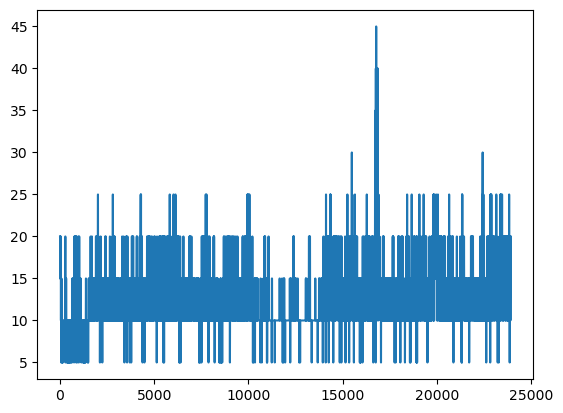

In [33]:
plt.figure(figsize=[6,6])
plt.plot(positives)
plt.plot(positives_testset["eynsham"])

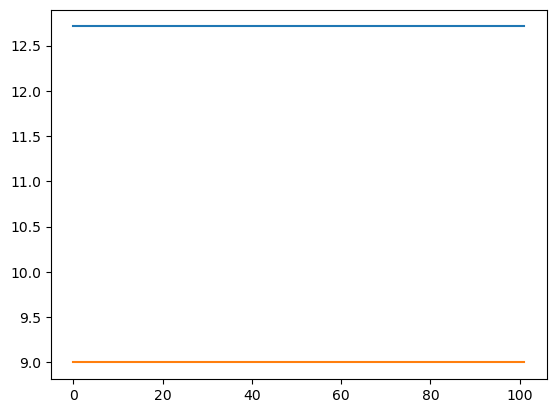

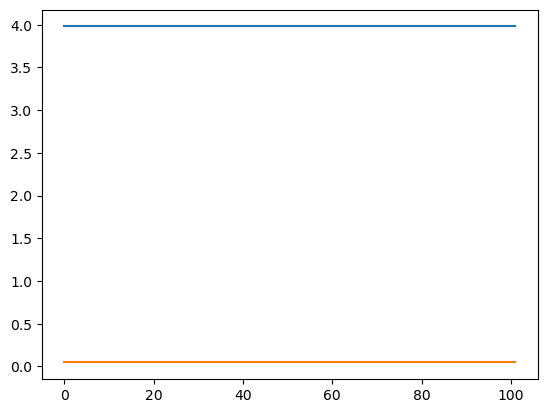

In [34]:
plt.plot(positives['eynsham'])
plt.plot(positives["nordland"])

plt.figure()
plt.plot(positive_stds['eynsham'])
plt.plot(positive_stds["nordland"])

In [11]:
# positives_refset=torch.load("avg_positives_per_range100_ref.pth")
positives_testset=torch.load("avg_positives_per_range100_tests.pth")
# std_positives_refset=torch.load("std_positives_per_range100_ref.pth")
std_positives_testset=torch.load("std_positives_per_range100_tests.pth")
print(positives_refset['nordland'][25])
print(positives_refset['eynsham'][25])
print(positives_testset['eynsham'][25])


NameError: name 'positives_refset' is not defined

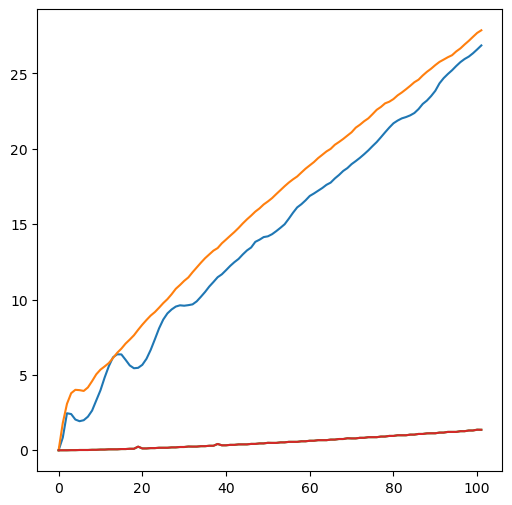

In [12]:
plt.figure(figsize=[6,6])
plt.plot(positive_stds['eynsham'])
plt.plot(std_positives_testset["eynsham"])
plt.plot(positive_stds['nordland'])
plt.plot(std_positives_testset["nordland"])

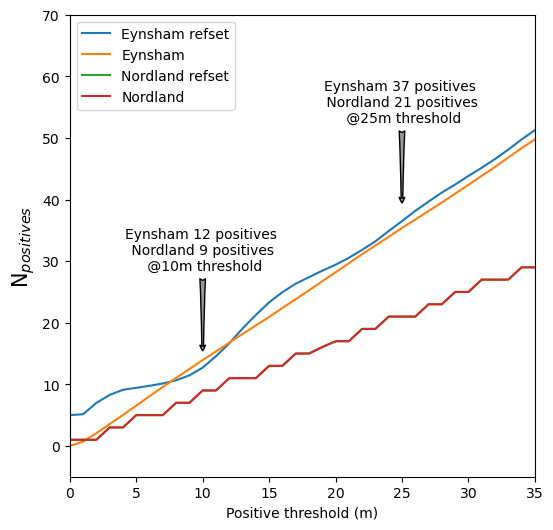

In [46]:
plt.figure(figsize=[6,6])
plt.plot(positives_refset['eynsham'])
plt.plot(positives_testset["eynsham"])
plt.plot(positives_refset['nordland'])
plt.plot(positives_testset["nordland"])
plt.annotate('Eynsham 12 positives \n Nordland 9 positives \n @10m threshold', xy=(10,15), xycoords='data',
            xytext=(0,60), textcoords='offset points',ha="center",
            arrowprops=dict(arrowstyle='fancy',fc='0.6', 
                            connectionstyle="angle3,angleA=0,angleB=-90"))
plt.annotate('Eynsham 37 positives \n Nordland 21 positives \n @25m threshold', xy=(25,39), xycoords='data',
            xytext=(0,60), textcoords='offset points',ha="center",
            arrowprops=dict(arrowstyle='fancy',fc='0.6', 
                            connectionstyle="angle3,angleA=0,angleB=-90"))
plt.xlim([0,35])
plt.ylim([-5,70])
plt.ylabel("N$_{positives}$",size=15)
plt.xlabel("Positive threshold (m)")
plt.legend(["Eynsham refset",  "Eynsham","Nordland refset", "Nordland"],loc='upper left')
plt.savefig("positives_largedataset.png")

In [8]:
dataset_list=[]

datasets_features={}

for dataset_name in wanted_datasets:
    batch_id=-1
    print(f"extracting features of {dataset_name}")
    eval_ds= BaseDataset(args,datasets_folder="/scratch/mzaffar/olaf/datasets_vg/datasets",dataset_name=dataset_name,split='test')
    test_method=args.test_method
    model = model.eval()



    with torch.no_grad():
        print("Extracting database features for evaluation")
        # For database use "hard_resize", although it usually has no effect because database images have same resolution
        eval_ds.test_method = "hard_resize"
        database_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num)))
        database_dataloader = DataLoader(dataset=database_subset_ds, num_workers=args.num_workers,
                                         batch_size=args.infer_batch_size, pin_memory=(args.device == "cuda"))
            
        idx=np.linspace(0,len(database_dataloader)-1,len(database_dataloader))
#         print(idx.shape)

        database_features=[None]*(min(n_batches,len(idx)))
        queries_features=[None]*(min(n_batches,len(idx)))
        choices=list(np.random.choice(idx,min(len(idx),n_batches),replace=False))
        
#         if test_method == "nearest_crop" or test_method == 'maj_voting':
#             all_features = np.empty((5 * eval_ds.queries_num + eval_ds.database_num, args.features_dim), dtype="float32")
#         else:
#             all_features = np.empty((len(eval_ds), args.features_dim), dtype="float32")

        for i, (inputs, indices) in tqdm(enumerate(database_dataloader)):
            if i not in choices:
                continue
            batch_id+=1
            features = model(inputs.to(args.device))
            features = features.cpu().numpy()
            database_features[batch_id]=features
        
        print("Extracting queries features for evaluation")
        queries_infer_batch_size = 1 if test_method == "single_query" else args.infer_batch_size
        eval_ds.test_method = test_method
        queries_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num, eval_ds.database_num+eval_ds.queries_num)))
        queries_dataloader = DataLoader(dataset=queries_subset_ds, num_workers=args.num_workers,
                                        batch_size=queries_infer_batch_size, pin_memory=(args.device == "cuda"))
        
        batch_id=-1
        if use_queries:
            for i, (inputs, indices) in tqdm(enumerate(queries_dataloader)):
                if i not in choices:
                    continue
                batch_id+=1
                features = model(inputs.to(args.device))
                features = features.cpu().numpy()
                queries_features[batch_id]=features
            
    database_features=np.vstack(database_features)
    if use_queries:
        queries_features =np.vstack(queries_features)
    print(f"made database features with shape{database_features.shape} and {queries_features.shape if use_queries else  '.'}")
    
    datasets_features[dataset_name]=database_features
    if use_queries:
        datasets_features[dataset_name+"_queries"]=queries_features
#     np.save(f"{dataset_name}_queries.npy",queries_features)
#     np.save(f"{dataset_name}_database.npy",database_features)
#     features_lists.append(queries_features)
#     features_lists.append(database_features)
#     features_lists_lengths.append(len(queries_features))
#     features_lists_lengths.append(len(database_features))
    

extracting features of amstertime
Extracting database features for evaluation


77it [00:15,  4.86it/s]

Extracting queries features for evaluation



77it [00:14,  5.33it/s]


made database features with shape(1231, 12288) and (1231, 12288)
extracting features of nordland
Extracting database features for evaluation


...

made database features with shape(23935, 12288) and (23935, 12288)
extracting features of sped
Extracting database features for evaluation


38it [00:09,  4.08it/s]

Extracting queries features for evaluation



38it [00:10,  3.80it/s]


made database features with shape(607, 12288) and (607, 12288)


In [9]:
from datasets_ws import path_to_pil_img

In [10]:
idx=np.linspace(0,len(train_dataloader)-1,len(train_dataloader))
print(idx.shape)
choices=list(np.random.choice(idx,n_batches*(2 if not use_queries else 4)))
all_features = []
with torch.no_grad():
    
    for i,(inputs, indices) in tqdm(enumerate(train_dataloader)):
        if i not in choices:
            continue
        inputs=inputs.squeeze()
#         print(inputs.shape,indices,all_features.shape)
        features = model(inputs.to(args.device))
        features = features.cpu().numpy()
#         print(features.shape)
        all_features.append(features)
    all_features=np.vstack(all_features)
    
#     datasets_features["train"]=dim_reduction.transform(all_features)
datasets_features["train"]=all_features
#     features_lists.append(all_features)
#     features_lists_lengths.append(len(all_features))

(4025,)


4025it [28:56,  2.32it/s]


In [11]:
all_features=np.vstack(datasets_features.values())
os.environ["MKL_NUM_THREADS"]      = str(6)                                             # num of threads
os.environ["NUMEXPR_NUM_THREADS"]  = str(6)                                             # num of threads
os.environ["OMP_NUM_THREADS"]      = str(6)                                            # num of threads
pca_compos=512
dim_reduction=PCA(n_components=pca_compos)
small_features=dim_reduction.fit_transform(all_features)

/tmp/ipykernel_2313041/2447163238.py:1: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  all_features=np.vstack(datasets_features.values())


In [12]:
nice_names={"amstertime":"Amstertime","nordland":"Nordland","eynsham":"Eynsham","sped":"SPEDtest","amstertime_queries":"Amstertime queries","nordland_queries":"Nordland queries","eynsham_queries":"Eynsham queries","sped_queries":"SPEDtest queries","train":"GSV-Cities","crica":"CricaVPR","boq":"BoQ","salad":"SALAD","pitts30k":"Pitts30k","pitts30k_queries":"Pitts30k queries"}

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Initialize t-SNE
perplexity=100
tsne = TSNE(n_components=2,perplexity=perplexity, random_state=0,verbose=1,n_iter=10000,n_jobs=6)

# Fit and transform the data
tsne_results = tsne.fit_transform(small_features)



[t-SNE] Computing 301 nearest neighbors...
[t-SNE] Indexed 171124 samples in 24.714s...


In [ ]:
print(datasets_features.keys())

In [ ]:
# Plot the t-SNE results
figure = plt.figure(figsize=(8, 8))
datasets_features
num=0
dataset_tsne={}
for dataset_name in list(datasets_features.keys()):
    num_prev=num
#     if dataset_name == 'train':
#         continue
    num+=len(datasets_features[dataset_name])
    dataset_tsne[dataset_name]=tsne_results[num_prev:num]
    plt.scatter(tsne_results[num_prev:num, 0], tsne_results[num_prev:num, 1], label=nice_names[dataset_name],alpha=0.5)

plt.legend()
plt.title('DINOv2-CricaVPR')

# plt.xlabel('t-SNE 1')
# plt.ylabel('t-SNE 2')
plt.grid(True)
plt.savefig(f"imgs/tsne_{method}_train_last_pca_{pca_compos}-{amount_of_test_features}imgs-{perplexity}per{'_withqueries' if use_queries else ''}.png",bbox_inches="tight")

plt.show()
figure2 = plt.figure(figsize=(8, 8))
for dataset_name in list(dataset_tsne.keys())[::-1]:
    plt.scatter(dataset_tsne[dataset_name][:,0], dataset_tsne[dataset_name][:,1], label=nice_names[dataset_name],alpha=0.1)
             
    


# plt.scatter(tsne_results[-len(datasets_features["train"]):, 0], tsne_results[-len(datasets_features["train"]):, 1], label="train data")
# plt.scatter(tsne_results[:, 0], tsne_results[:, 1], label="train data")
    
plt.legend()
plt.title('DINOv2-CricaVPR')

# plt.xlabel('t-SNE 1')
# plt.ylabel('t-SNE 2')
plt.grid(True)
plt.savefig(f"imgs/tsne_{method}_pca_{pca_compos}-{amount_of_test_features}imgs-{perplexity}per{'_withqueries' if use_queries else ''}.png",bbox_inches="tight")
plt.show()

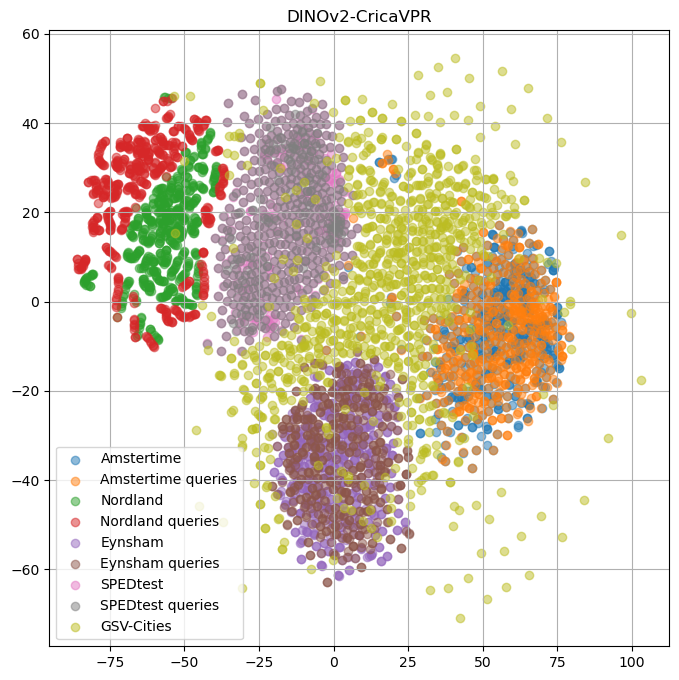

In [17]:
# Plot the t-SNE results
figure = plt.figure(figsize=(8, 8))
datasets_features
num=0
for dataset_name in datasets_features.keys():
    num_prev=num
#     if dataset_name == 'train':
#         continue
    num+=len(datasets_features[dataset_name])
    plt.scatter(tsne_results[num_prev:num, 0], tsne_results[num_prev:num, 1], label=nice_names[dataset_name],alpha=0.5)
        
        
    


# plt.scatter(tsne_results[-len(datasets_features["train"]):, 0], tsne_results[-len(datasets_features["train"]):, 1], label="train data")
# plt.scatter(tsne_results[:, 0], tsne_results[:, 1], label="train data")
    
plt.legend()
plt.title('DINOv2-CricaVPR')

# plt.xlabel('t-SNE 1')
# plt.ylabel('t-SNE 2')
plt.grid(True)
# plt.savefig(f"tsne-{amount_of_test_features}imgs-{perplexity}per{'_withqueries' if use_queries else ''}.png",bbox_inches="tight")
plt.show()

In [8]:
nice_names={"amstertime":"Amstertime","nordland":"Nordland","eynsham":"Eynsham","sped":"SPEDtest"}

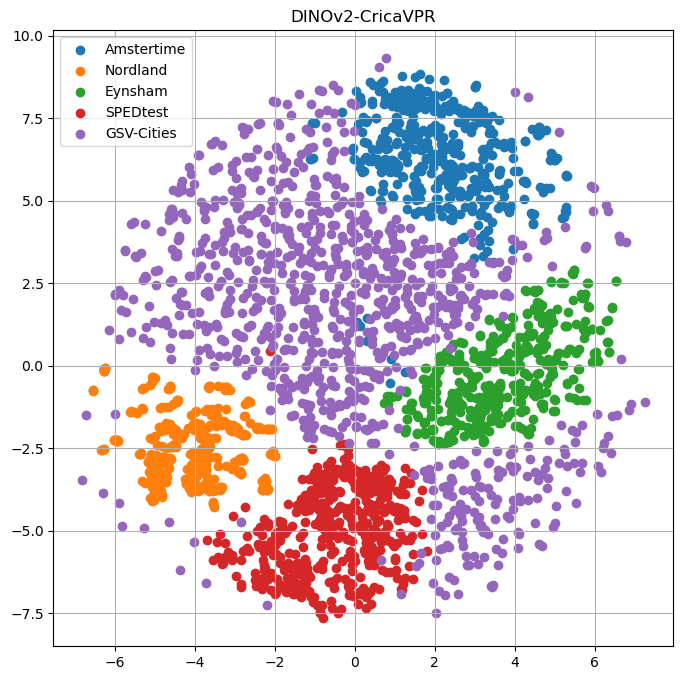

In [167]:
# Plot the t-SNE results
figure = plt.figure(figsize=(8, 8))
datasets_features
num=0
for dataset_name in datasets_features.keys():
    num_prev=num
    num+=len(datasets_features[dataset_name])
    plt.scatter(tsne_results[num_prev:num, 0], tsne_results[num_prev:num, 1], label=nice_names[dataset_name])
        
        
    


# plt.scatter(tsne_results[-len(datasets_features["train"]):, 0], tsne_results[-len(datasets_features["train"]):, 1], label="train data")
# plt.scatter(tsne_results[:, 0], tsne_results[:, 1], label="train data")
    
plt.legend()
plt.title('DINOv2-CricaVPR')

# plt.xlabel('t-SNE 1')
# plt.ylabel('t-SNE 2')
plt.grid(True)
plt.savefig(f"tsne-{amount_of_test_features}imgs-{perplexity}per.png")
plt.show()

In [4]:
results_datasets={"amstertime":{"boq":[62.6,	81.6,	85.5	,88.5	,64.9,	83.8,	87.6	,90.9],
"salad":[58.2,	78.8,	83.7,	87.8,	58.1,	78.6,	83.8,	87.7],
"crica":[64.3,	82.4,	87.2,	91.3,	64.9,	83.2,	87.2,	91.6]},
                 "sped":{"boq":[92.9,	95.7,	97.0,	98.0,	92.8,	95.7,	97.0,	98.2],
         "salad":[92.3,	96.0,	96.9,	97.4,	92.3,	96.2,	96.9,	97.0],
"crica":[91.9,	95.4,	96.7,	97.0,	92.1,	95.9,	96.7,	97.4]},
        "nordland":{"boq":[88.7,	95.1	,96.9	,98.2,	91.0,	96.0,	97.5,	98.4],
"salad":[83.2,	91.8	,94.5,	96.4	,87.7	,94.6	,96.4	,97.7],
                 "crica":[88.6,94.0,96.5,97.7,	92.4,	96.6,	97.8,	98.6]}, 
"eynsham":{"boq":[92.1,	95.5,	96.4,	97.0,	92.2,	95.8,	96.6,	97.2],
"salad":[91.4,	95.0,	95.9,	96.7,	92.1,	95.6,	96.6,	97.1],
"crica":[91.6,	95.0,	95.8,	96.4,	92.0,	95.5,	96.4,	97.0]}}



# torch.save(results,"recalls_final.pth")

In [ ]:
62.6	81.6	85.5	88.5	64.9	83.8	87.6	90.9
58.2	78.8	83.7	87.8	58.1	78.6	83.8	87.7
64.3	82.4	87.2	91.3	64.9	83.2	87.2	91.6
92.9	95.7	97.0	98.0	92.8	95.7	97.0	98.2
92.3	96.0	96.9	97.4	92.3	96.2	96.9	97.0
91.9	95.4	96.7	97.0	92.1	95.9	96.7	97.4
88.7	95.1	96.9	98.2	91.0	96.0	97.5	98.4
83.2	91.8	94.5	96.4	87.7	94.6	96.4	97.7
88.6	94.9	96.5	97.7	92.4	96.6	97.8	98.6
92.1	95.5	96.4	97.0	92.2	95.8	96.6	97.2
91.4	95.0	95.9	96.6	92.1	95.6	96.5	97.1
91.6	95.0	95.8	96.4	92.0	95.5	96.4	97.0


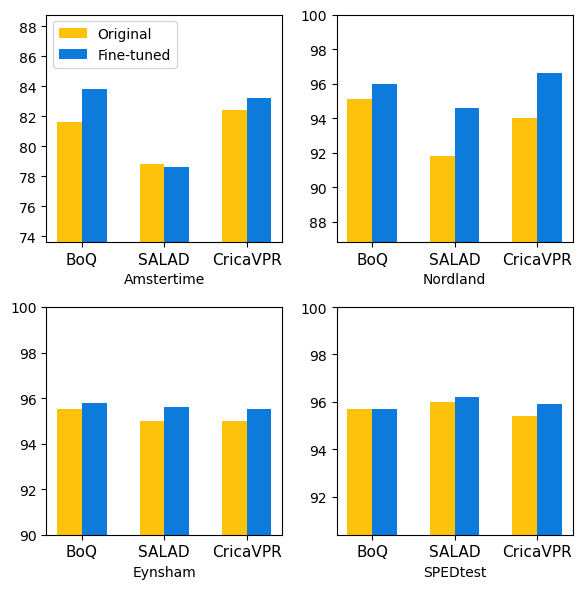

In [10]:
# recall_value=0
recall_value=1
height_margin=5
method_names=list(results_datasets["amstertime"].keys())
x = np.arange(3)
width = 0.3
plot_dataset_names=["amstertime","nordland","eynsham","sped"]
fig, ((ax1,ax2),(ax3,ax4))=plt.subplots(2,2,figsize=(6,6))

axes=[ax1,ax2,ax3,ax4]
for i,dataset_name in enumerate(plot_dataset_names):
    ax=axes[i]
    ax.set_xlabel(nice_names[dataset_name])
    results=np.array(list(results_datasets[dataset_name].values()))
    plot_names=["BoQ","SALAD","CricaVPR"]
    ax.set_ylim([np.min(results[:,recall_value::4])-height_margin,min(np.max(results[:,recall_value::4])+height_margin,100)])
    ax.bar(x-width/2, results[:,recall_value], width, label='Original', color=np.array([255,194,10])/255)
    ax.bar(x+width/2, results[:,recall_value+4], width, label='Fine-tuned',  color=np.array([12,123,220])/255)
    ax.set_xticks([0,1,2], plot_names, fontsize=11)
    if i==0:
        ax.legend(loc="upper left")
    
fig.tight_layout()
plt.savefig("results_fig1.png")

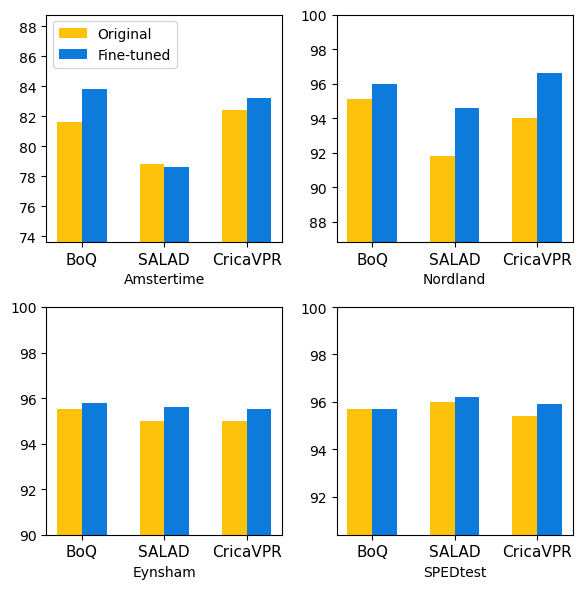

In [13]:
recall_value=1
height_margin=5
method_names=list(results_datasets["amstertime"].keys())
x = np.arange(3)
width = 0.3
plot_dataset_names=["amstertime","nordland","eynsham","sped"]
fig, ((ax1,ax2),(ax3,ax4))=plt.subplots(2,2,figsize=(6,6))

axes=[ax1,ax2,ax3,ax4]
for i,dataset_name in enumerate(plot_dataset_names):
    ax=axes[i]
    ax.set_xlabel(nice_names[dataset_name])
    results=np.array(list(results_datasets[dataset_name].values()))
    plot_names=["BoQ","SALAD","CricaVPR"]
    ax.set_ylim([np.min(results[:,recall_value::4])-height_margin,min(np.max(results[:,recall_value::4])+height_margin,100)])
    ax.bar(x-width/2, results[:,recall_value], width, label='Original', color=np.array([255,194,10])/255)
    ax.bar(x+width/2, results[:,recall_value+4], width, label='Fine-tuned',  color=np.array([12,123,220])/255)
    ax.set_xticks([0,1,2], plot_names, fontsize=11)
    if i==0:
        ax.legend(loc="upper left")
    
fig.tight_layout()
# plt.savefig("results_fig1.png")

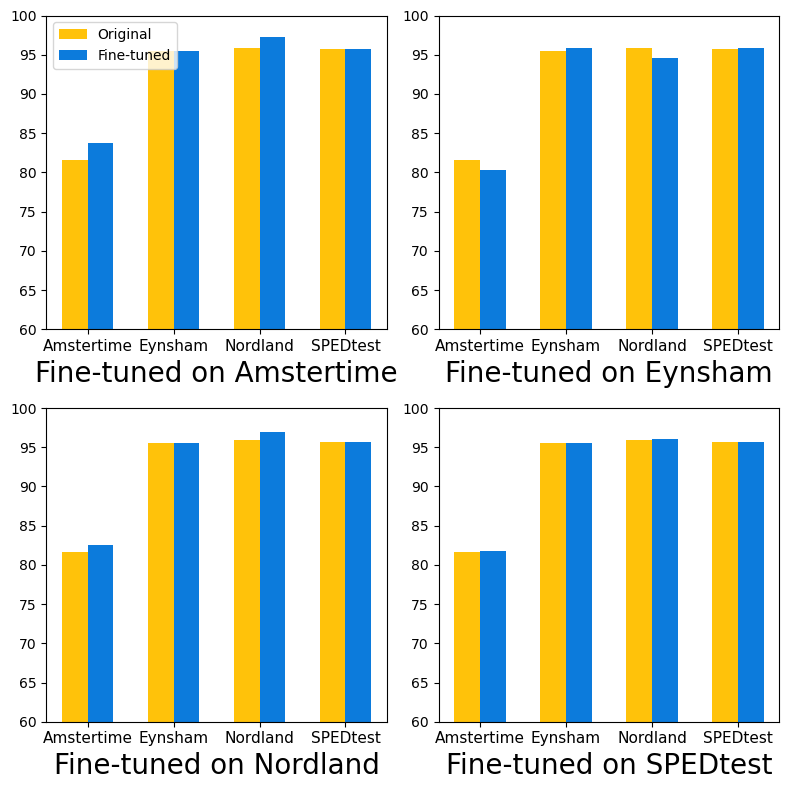

In [19]:
# -*- coding: utf-8 -*-
"""
Created on Wed Nov 20 12:56:10 2024

@author: olafv
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv("import_boq.csv")

# # recall_value=0
height_margin=5
# method_names=list(results_datasets["amstertime"].keys())
x = np.arange(4)
width=0.3

nice_names={"amstertime":"Amstertime","nordland":"Nordland","eynsham":"Eynsham","sped":"SPEDtest"}

# plt.xticks(fontsize=15) 

plt.rc('axes', labelsize=20) 

plot_dataset_names=np.array(["amstertime","eynsham","nordland","sped"])
if False:
    fig, ((ax1,ax2,ax3,ax4))=plt.subplots(1,4,figsize=(16,4))
else:
    
    fig, ((ax1,ax2),(ax3,ax4))=plt.subplots(2,2,figsize=(8,8))

axes=[ax1,ax2,ax3,ax4]


original=np.array([0]*4)
recall_value=1
finetuned=np.array([0]*4)
filter_name="fine tune set" #"Test set"#
amstertime= df.loc[df[filter_name] == "Amstertime"].values
amstertime_res=amstertime[:,-8:]
# amstertime_res=np.vstack([amstertime_res,amstertime[0,3:7]])
# amstertime_res=[amstertime[]]
nordland= df.loc[df[filter_name] == "Nordland"].values
nordland_res=nordland[:,-8:]
# nordland_res=np.vstack([nordland_res,nordland[0,3:7]])
sped= df.loc[df[filter_name] == "SPED"].values
sped_res=sped[:,-8:]
# sped_res=np.vstack([sped_res,sped[0,3:7]])
eynsham= df.loc[df[filter_name] == "Eynsham"].values
eynsham_res=eynsham[:,-8:]
# eynsham_res=np.vstack([eynsham_res,eynsham[0,3:7]])

results=[amstertime_res,eynsham_res,nordland_res,sped_res]
for i,dataset_name in enumerate(plot_dataset_names):
    ax=axes[i]
#     ax.set_aspect('square', adjustable='box')
#     plt.axis("square")
    good_results=np.array(results[i])
    original=good_results[:,:4]
    fine=good_results[:,-4:]
    ax.set_xlabel(f"Fine-tuned on {nice_names[dataset_name]}")
    ax.set_ylim([60,100])
    # results=np.array(list(results_datasets[dataset_name].values()))
    plot_names=["Amstertime","Eynsham", "Nordland","SPEDtest"]
    ax.bar(x-width/2, original[:,recall_value], width, label='Original', color=np.array([255,194,10])/255)
    ax.bar(x+width/2, fine[:,recall_value], width, label='Fine-tuned',  color=np.array([12,123,220])/255)
    ax.set_xticks([0,1,2,3], plot_names, fontsize=11)
    # ax.set_ylim([np.min(good_results[:,recall_value])-height_margin,min(np.max(good_results[:,recall_value])+height_margin,100)])
    
    
    if i==0:
        ax.legend(loc="upper left")
    
fig.tight_layout()
# plt.axis("equal")
# plt.savefig("ablation_fig_boq.png")
plt.show()


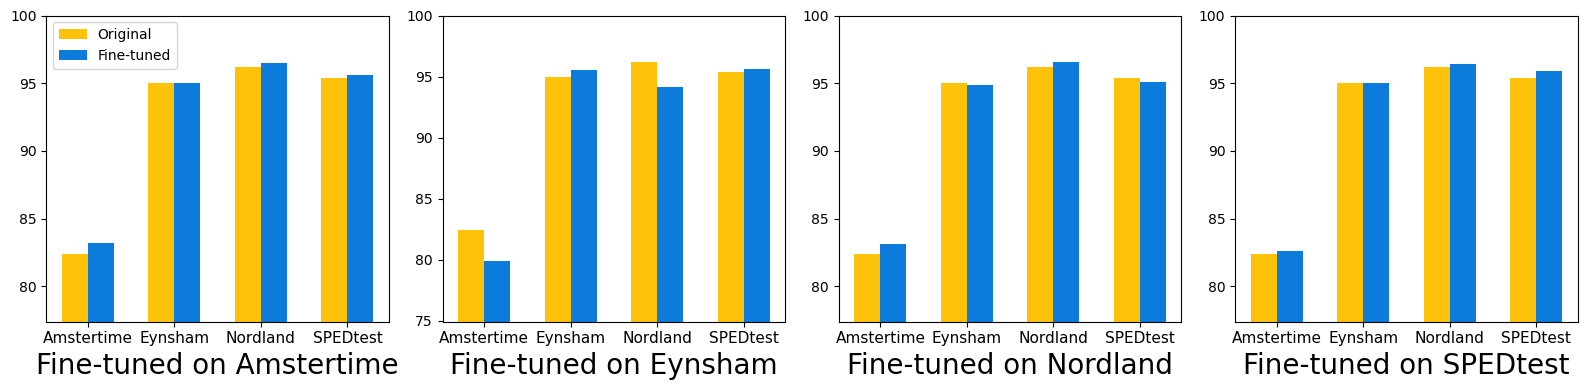

In [24]:
# -*- coding: utf-8 -*-
"""
Created on Wed Nov 20 12:56:10 2024

@author: olafv
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv("import.csv")

# # recall_value=0
height_margin=5
# method_names=list(results_datasets["amstertime"].keys())
x = np.arange(4)
width=0.3
recall_value=1

nice_names={"amstertime":"Amstertime","nordland":"Nordland","eynsham":"Eynsham","sped":"SPEDtest"}

# plt.xticks(fontsize=15) 

plt.rc('axes', labelsize=20) 

plot_dataset_names=np.array(["amstertime","eynsham","nordland","sped"])
fig, ((ax1,ax2,ax3,ax4))=plt.subplots(1,4,figsize=(16,4))

axes=[ax1,ax2,ax3,ax4]


original=np.array([0]*4)
finetuned=np.array([0]*4)
filter_name="fine tune set" #"Test set"#
amstertime= df.loc[df[filter_name] == "Amstertime"].values
amstertime_res=amstertime[:,-8:]
# amstertime_res=np.vstack([amstertime_res,amstertime[0,3:7]])
# amstertime_res=[amstertime[]]
nordland= df.loc[df[filter_name] == "Nordland"].values
nordland_res=nordland[:,-8:]
# nordland_res=np.vstack([nordland_res,nordland[0,3:7]])
sped= df.loc[df[filter_name] == "SPED"].values
sped_res=sped[:,-8:]
# sped_res=np.vstack([sped_res,sped[0,3:7]])
eynsham= df.loc[df[filter_name] == "Eynsham"].values
eynsham_res=eynsham[:,-8:]
# eynsham_res=np.vstack([eynsham_res,eynsham[0,3:7]])

results=[amstertime_res,eynsham_res,nordland_res,sped_res]
for i,dataset_name in enumerate(plot_dataset_names):
    ax=axes[i]
#     ax.set_aspect('square', adjustable='box')
#     plt.axis("square")
    good_results=np.array(results[i])
    original=good_results[:,:4]
    fine=good_results[:,-4:]
    ax.set_xlabel(f"Fine-tuned on {nice_names[dataset_name]}")
    ax.set_ylim([60,100])
    ax.set_ylim([np.min(np.array(good_results)[:,recall_value::4])-height_margin,100])
    
    # results=np.array(list(results_datasets[dataset_name].values()))
    plot_names=["Amstertime","Eynsham", "Nordland","SPEDtest"]
    ax.bar(x-width/2, original[:,recall_value], width, label='Original', color=np.array([255,194,10])/255)
    ax.bar(x+width/2, fine[:,recall_value], width, label='Fine-tuned',  color=np.array([12,123,220])/255)
    ax.set_xticks([0,1,2,3], plot_names, fontsize=11)
    # ax.set_ylim([np.min(good_results[:,recall_value])-height_margin,min(np.max(good_results[:,recall_value])+height_margin,100)])
    
    
    if i==0:
        ax.legend(loc="upper left")
    
fig.tight_layout()
# plt.axis("equal")
# plt.savefig("ablation_fig_flat.png")
plt.show()


In [ ]:
features_lists=np.array(features_lists)
np.save("all_features_crica.npy",features_lists)
np.save("all_lenghts.npy",features_lists_lenghts)

In [10]:
y=0
x=0
backbone_num=0
backbone_trainable=0
agg_trainable=0
agg_num=0
if method == "crica":
    for name, param in model.module.backbone.named_parameters():
        if "adapter" not in name:
            param.requires_grad = False
if method == "salad":
    for blk in model.backbone.model.blocks[:-model.backbone.num_trainable_blocks]:
    #     print(blk)
        for param in blk.parameters():
            param.requires_grad=False
model.train()
# print(model.module.backbone.blocks[5].attn)

for param in model.named_parameters():
#     print(param[0])
    y+=param[1].numel()
    if "backbone" in param[0]:
        backbone_num+=param[1].numel()
    if "backbone" not in param[0]:
        agg_num+=param[1].numel()
    if param[1].requires_grad and "backbone" in param[0]:
        backbone_trainable+=param[1].numel()
    
    if param[1].requires_grad and "backbone" not in param[0]:
        agg_trainable+=param[1].numel()
    
    if param[1].requires_grad:
#         print(param[0])
        x+=param[1].numel()


print(f"model: {method} with {y:.3e} parameters is trainable on {x:.3e} parameters the backbone has {backbone_num:.3e} parameter and {backbone_trainable:.3e} are trainable")
print(f"aggregator has {agg_num:.3e} parameter and is trainable on {agg_trainable:.3e}")

model: salad with 8.799e+07 parameters is trainable on 3.128e+07 parameters the backbone has 8.658e+07 parameter and 2.987e+07 are trainable
aggregator has 1.411e+06 parameter and is trainable on 1.411e+06
